<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/labs/lab_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# ICS40125 - Laboratorio N°09

**Objetivo**: Aplicar un flujo completo de **Machine Learning supervisado** para la clasificación de tumores mamarios, utilizando técnicas de preprocesamiento, reducción de dimensionalidad y modelos de clasificación con optimización de hiperparámetros.

> **Nota**: Puede ayudarse de algún asistente virtual como **ChatGPT, Gemini** u otros, así como del autocompletado de **Google Colab**, para avanzar en este laboratorio debido a su extensión.





<img src="https://www.svgrepo.com/show/1064/virus.svg" width = "300" align="center"/>



El **cáncer de mama** es una enfermedad caracterizada por la proliferación maligna de células epiteliales en los conductos o lobulillos mamarios. Surge cuando una célula acumula mutaciones que le otorgan la capacidad de dividirse de manera descontrolada, lo que da origen a un tumor. Este tumor puede permanecer localizado o, en casos más agresivos, invadir tejidos cercanos y propagarse a otras partes del organismo mediante metástasis.

El conjunto de datos **`BC.csv`** recopila información clínica y morfológica de pacientes con tumores mamarios, clasificados como **benignos** o **malignos**. Las características se obtienen a partir de imágenes digitalizadas de aspirados con aguja fina (FNA, por sus siglas en inglés) de masas mamarias. Dichas variables describen aspectos cuantitativos de los **núcleos celulares**, como su tamaño, forma, textura y homogeneidad.

Este tipo de información es fundamental para la detección temprana y clasificación de tumores, ya que permite entrenar modelos de **machine learning** capaces de apoyar el diagnóstico y diferenciar entre tumores benignos y malignos con mayor precisión.

A continuación, se procederá a cargar y explorar el conjunto de datos:



In [1]:
# Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importar herramientas de Scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Configuración de gráficos
%matplotlib inline
sns.set_palette("deep", desat=0.6)
sns.set(rc={'figure.figsize': (11.7, 8.27)})

# Cargar y preparar los datos
df = pd.read_csv("https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/labs/data/BC.csv")
df.set_index('id', inplace=True)

# Transformación de la variable objetivo
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0}).astype(int)

# Visualizar las primeras filas del DataFrame
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,
842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Con base en la información presentada, resuelva las siguientes tareas. Asegúrese de:

* Incluir el **código necesario** para ejecutar cada análisis.
* Explicar de manera **clara y fundamentada** los resultados obtenidos.
* Describir el **proceso seguido**, justificando las decisiones tomadas en cada etapa (preprocesamiento, elección de técnicas y parámetros, interpretación de resultados).





1. **Análisis exploratorio profundo (EDA):**

   * Examine la distribución de las variables, identifique valores atípicos y analice la correlación entre características.
   * Visualice las diferencias más relevantes entre tumores **benignos** y **malignos** utilizando gráficos adecuados (boxplots, histogramas, mapas de calor).
   * Discuta qué variables parecen tener mayor capacidad discriminativa.


--- Resumen Estadístico de las Variables ---
        diagnosis  radius_mean  texture_mean  perimeter_mean    area_mean  \
count  569.000000   569.000000    569.000000      569.000000   569.000000   
mean     0.372583    14.127292     19.289649       91.969033   654.889104   
std      0.483918     3.524049      4.301036       24.298981   351.914129   
min      0.000000     6.981000      9.710000       43.790000   143.500000   
25%      0.000000    11.700000     16.170000       75.170000   420.300000   
50%      0.000000    13.370000     18.840000       86.240000   551.100000   
75%      1.000000    15.780000     21.800000      104.100000   782.700000   
max      1.000000    28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.01

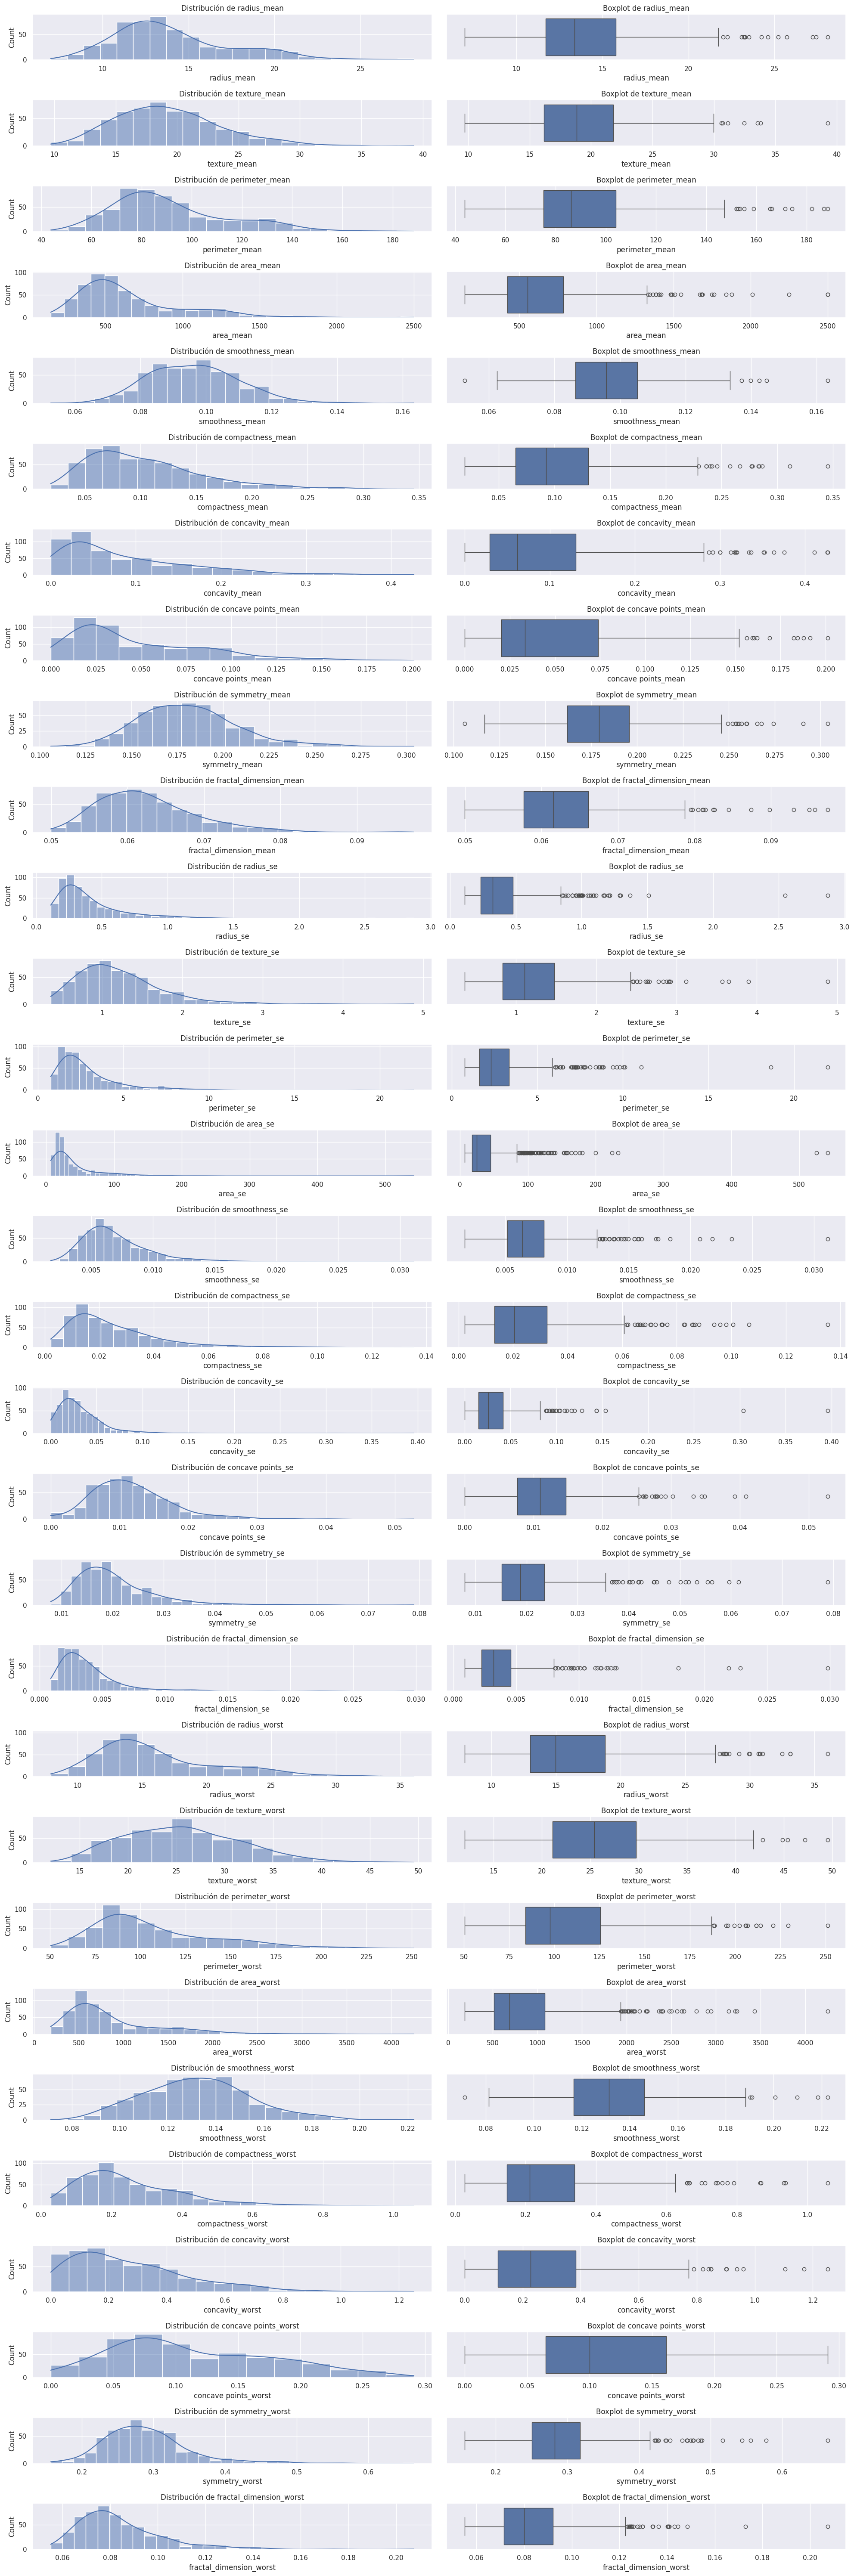


--- Matriz de Correlación ---


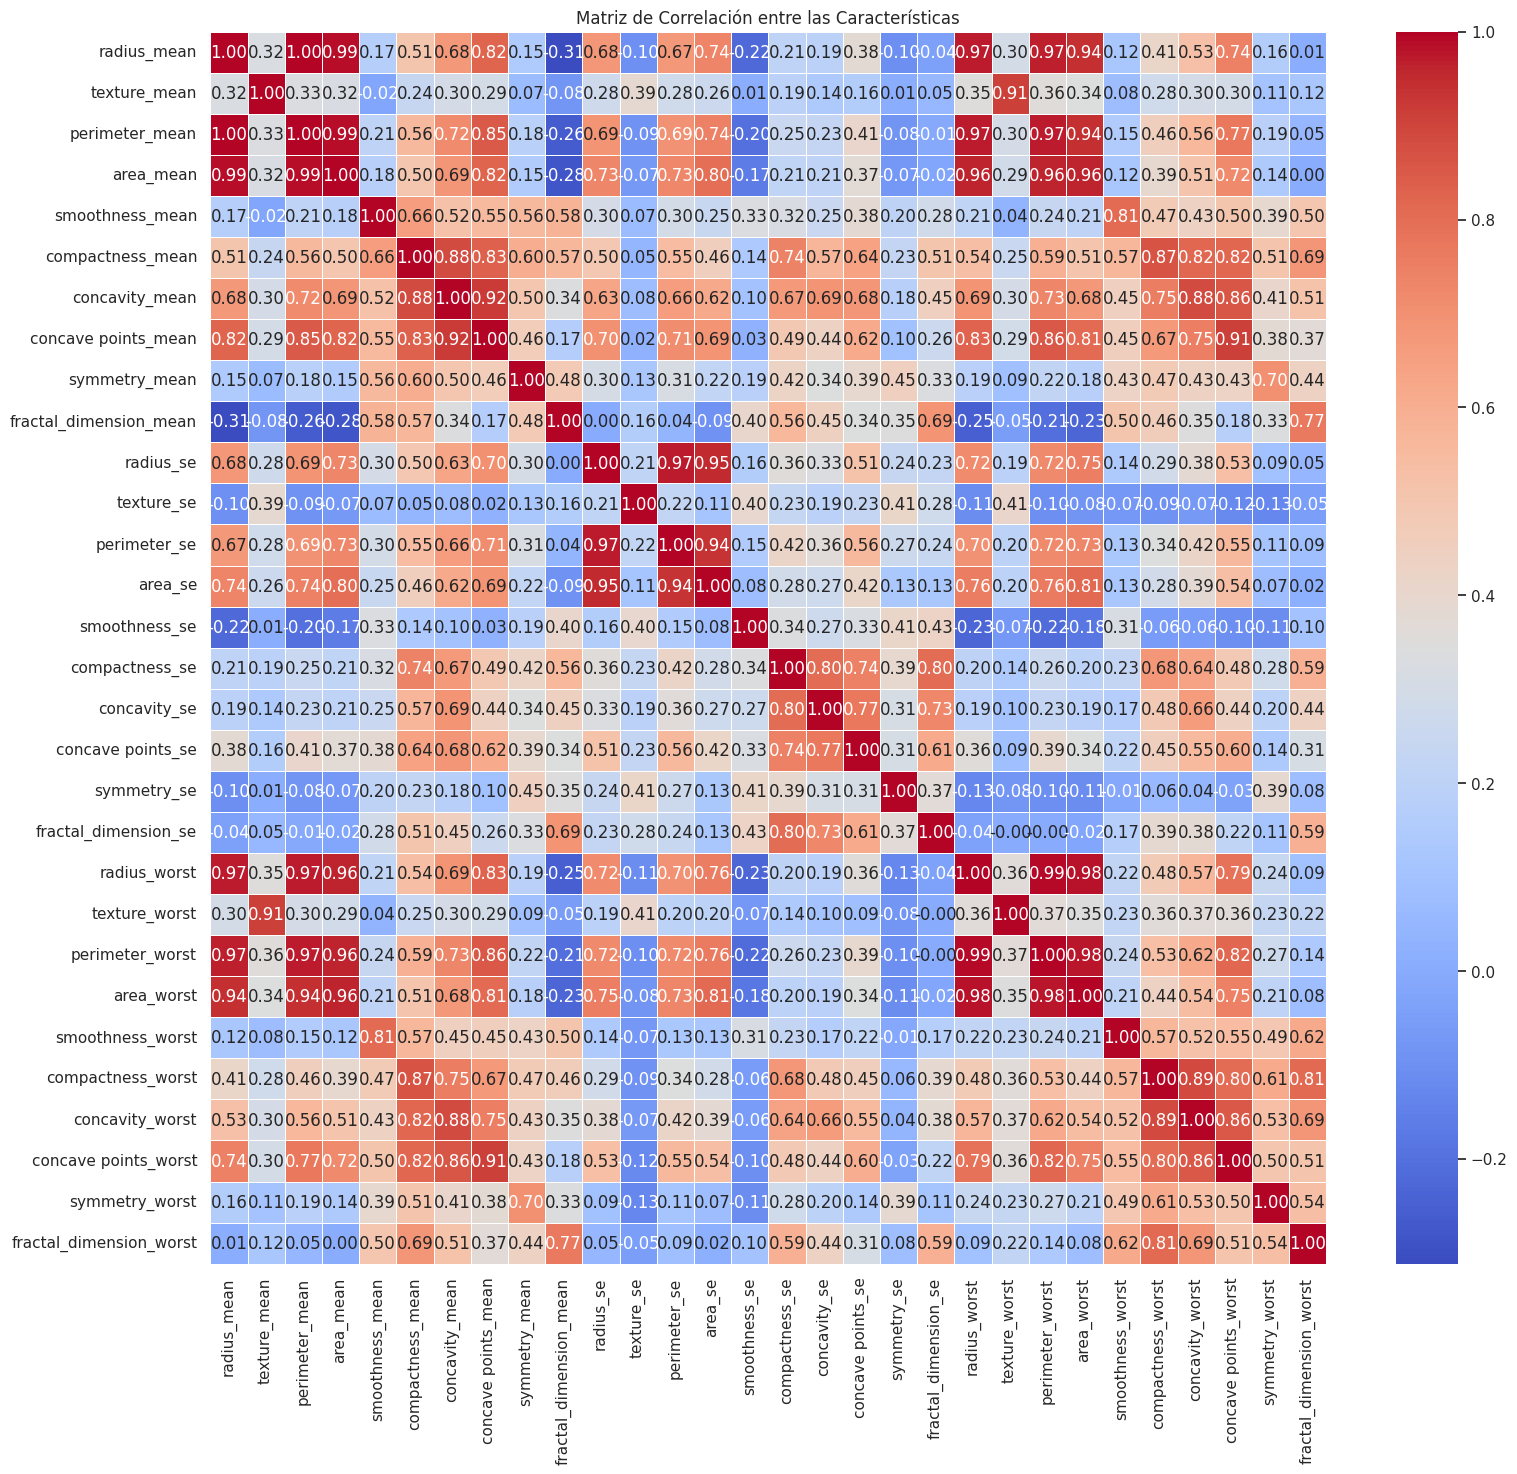


--- Correlación de las Características con la Variable Objetivo (Diagnosis) ---
diagnosis                  1.000000
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se       

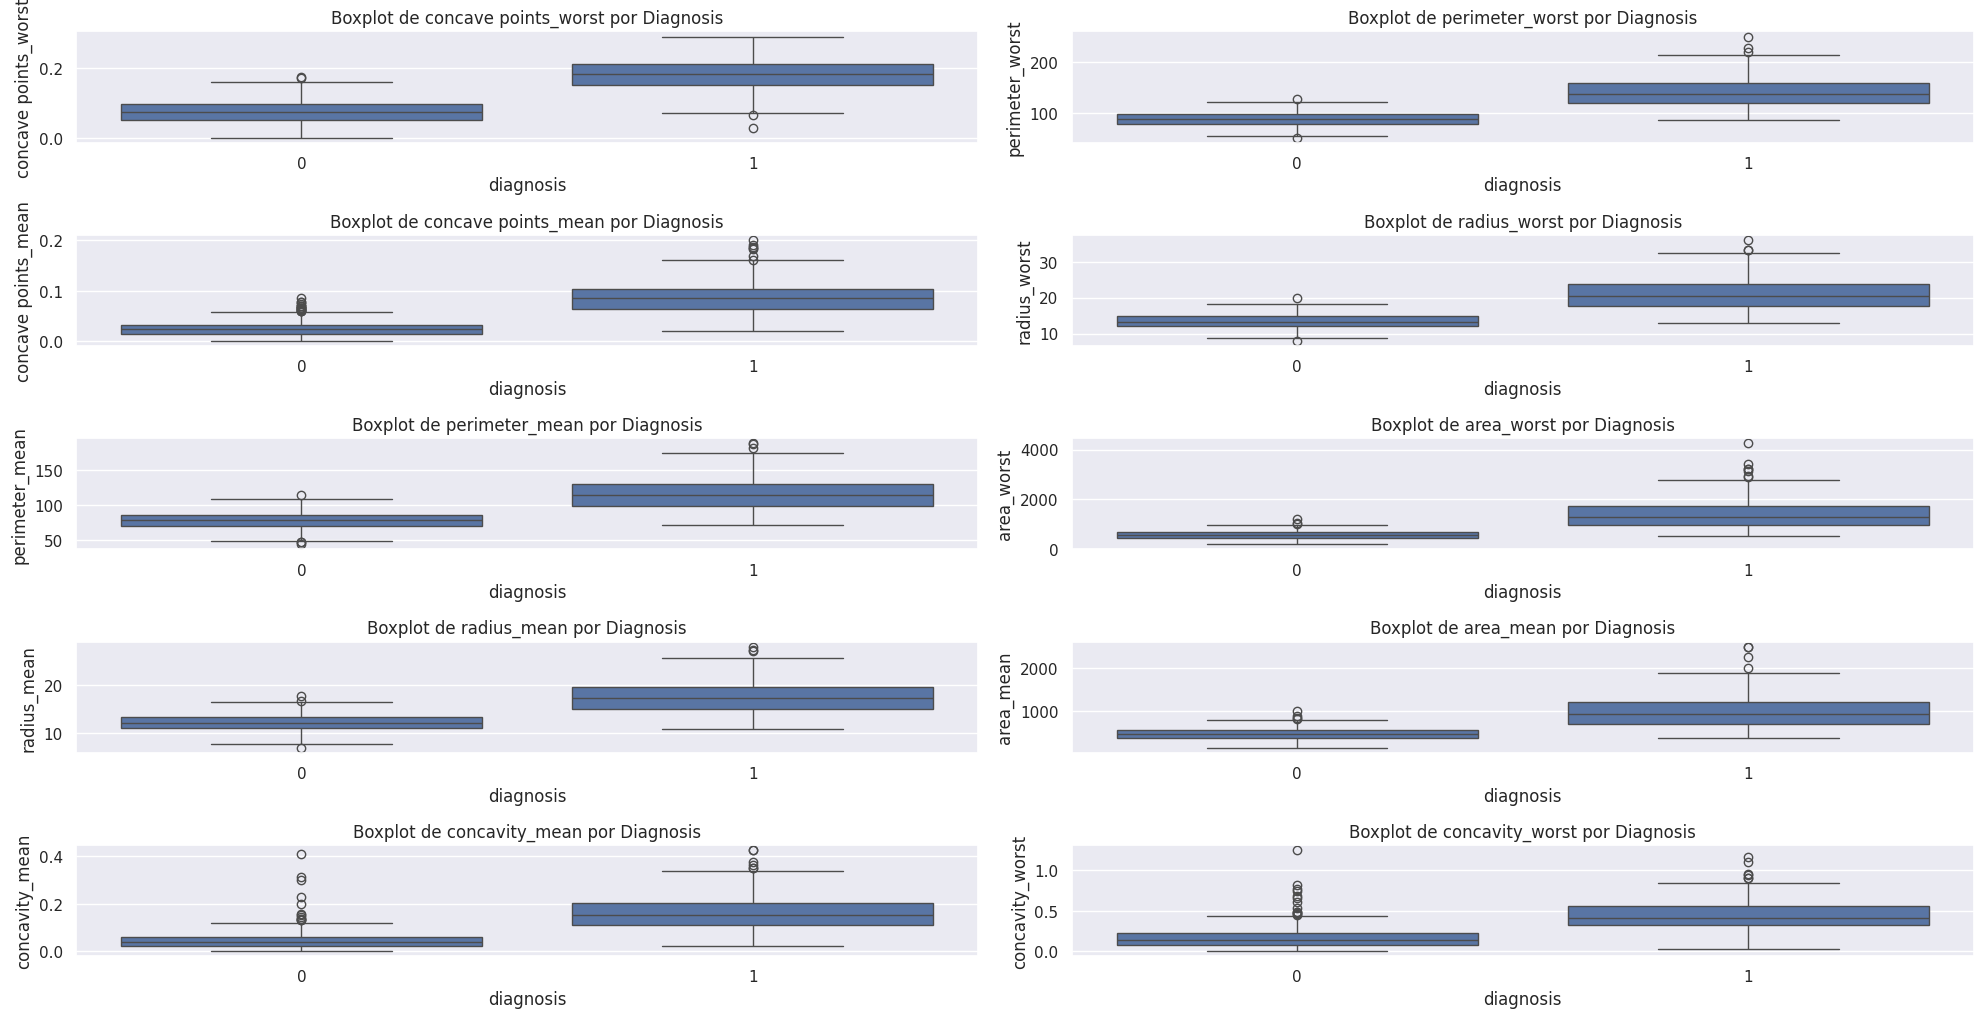

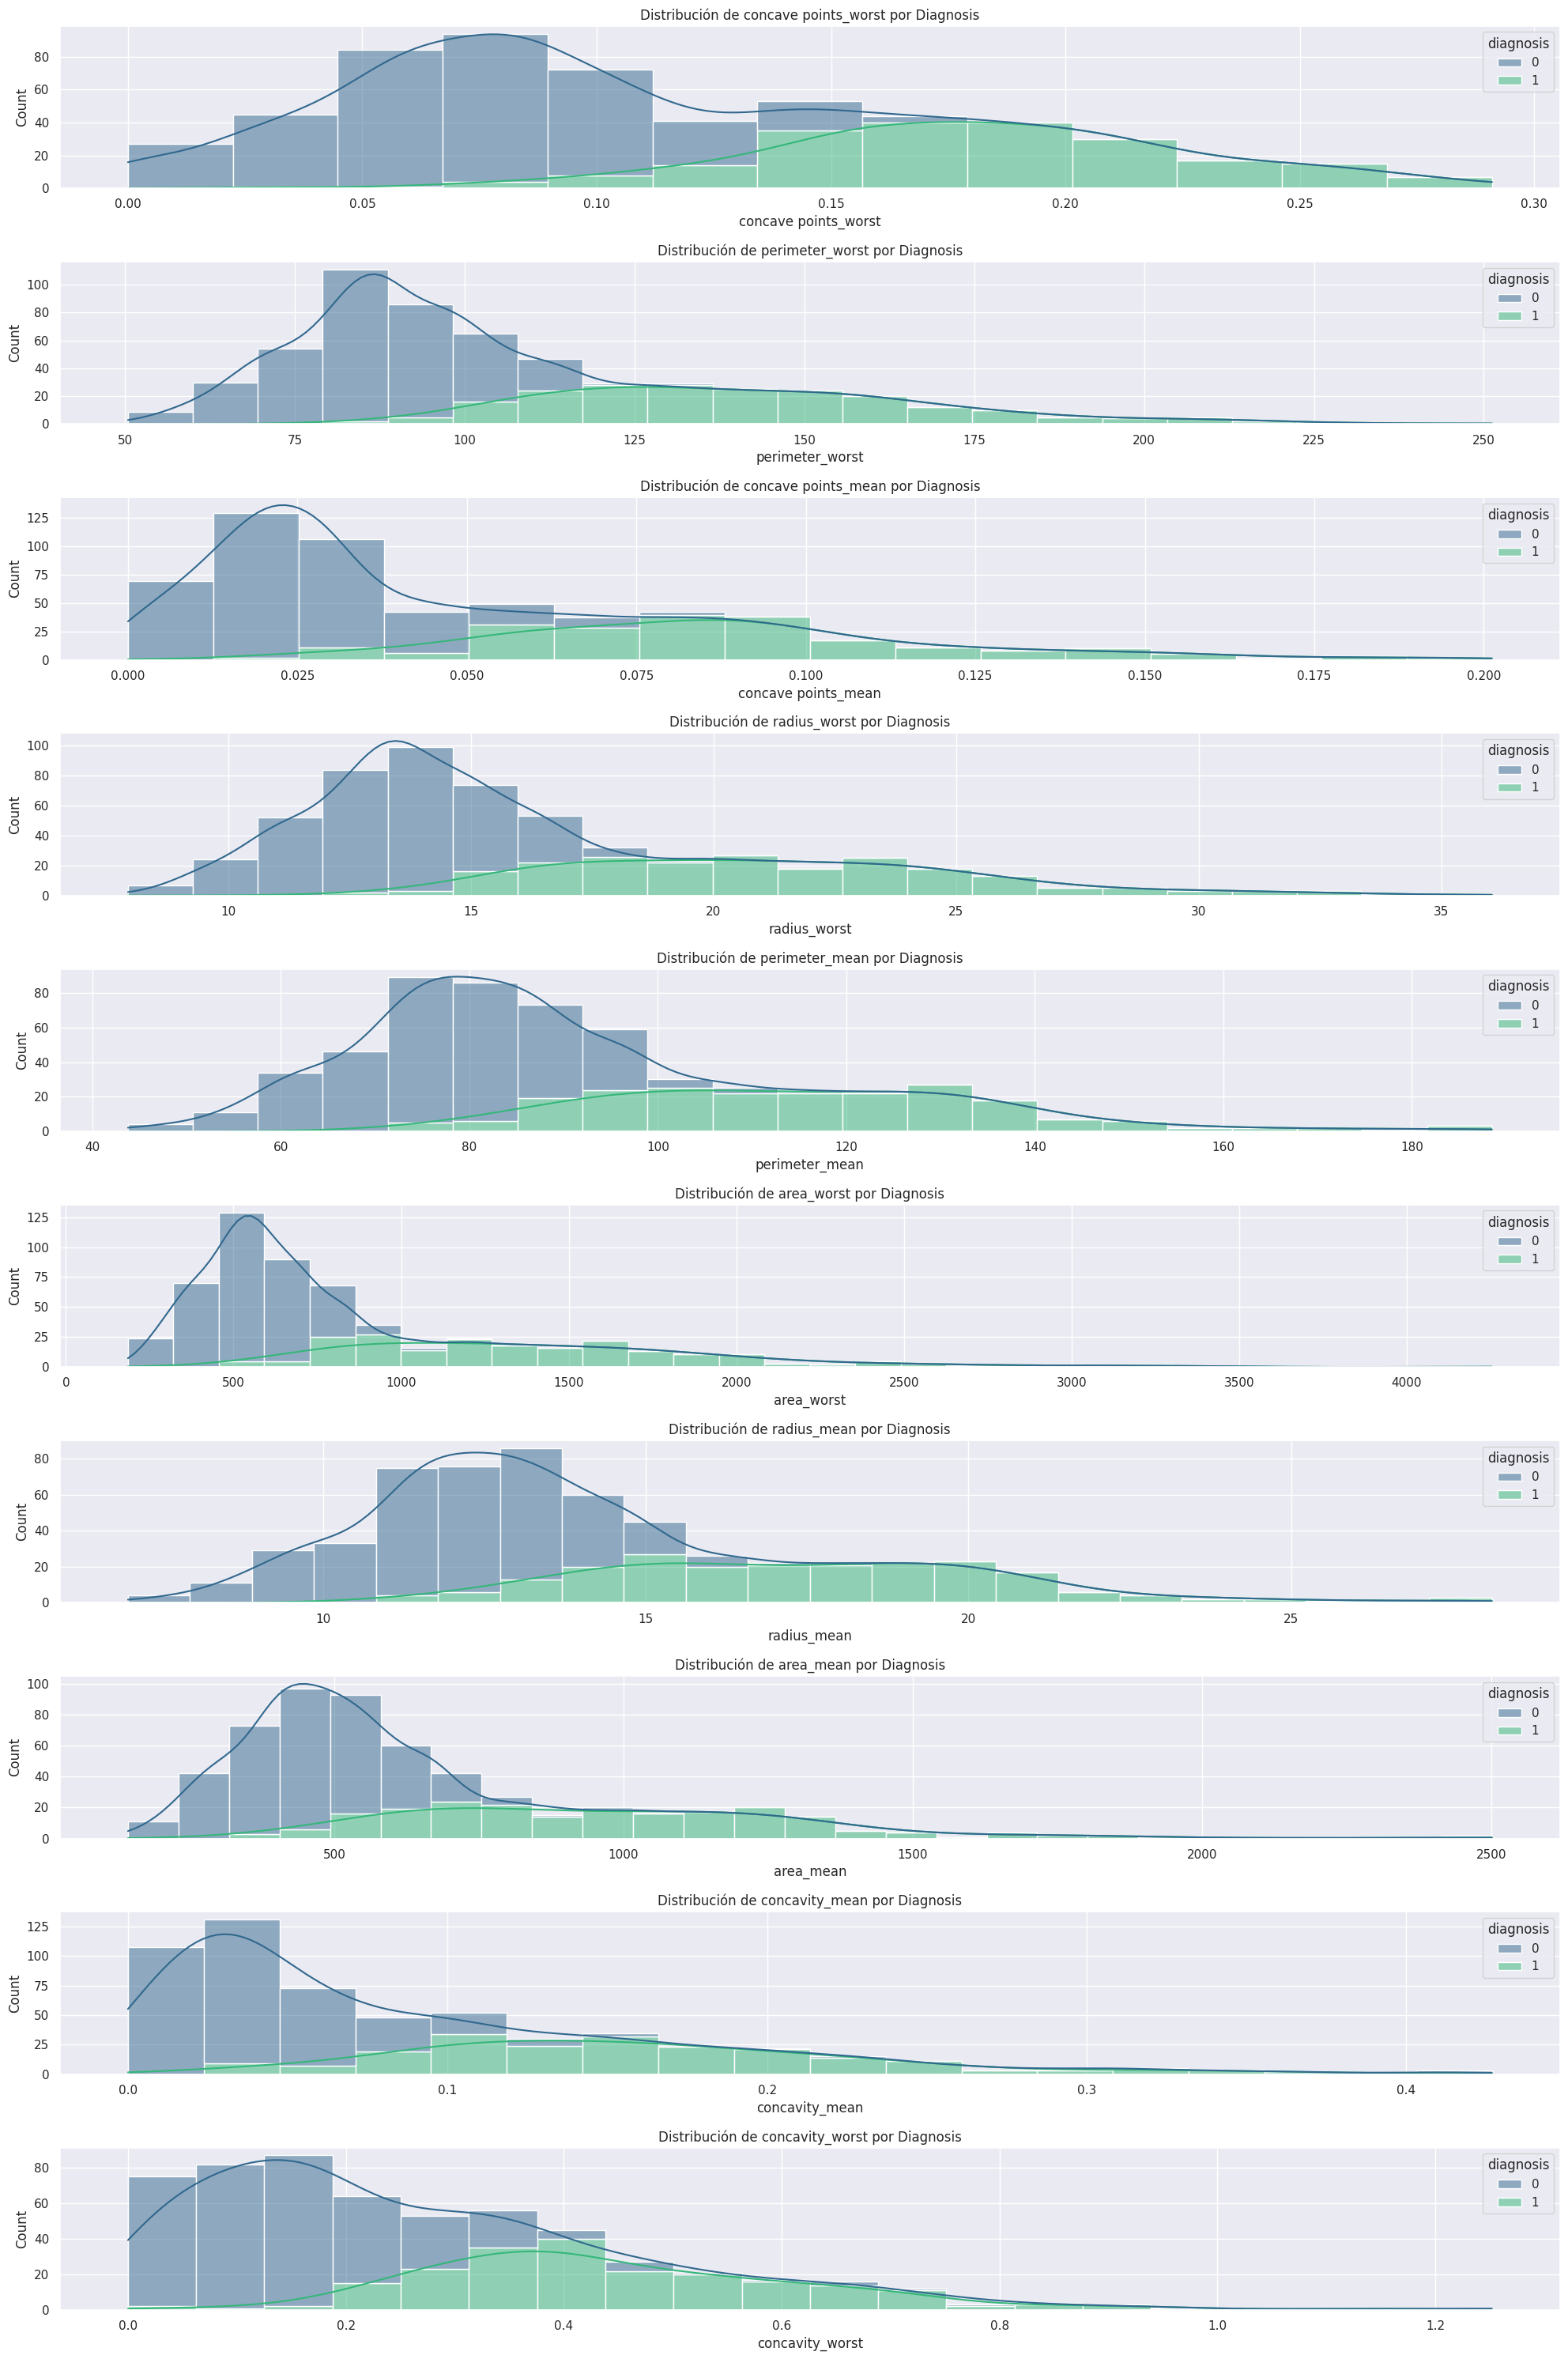


--- Discusión sobre Variables Discriminativas ---
Las variables con mayor capacidad discriminativa son aquellas que muestran una alta correlación (positiva o negativa) con la variable 'diagnosis' y que presentan distribuciones claramente separadas entre los grupos de tumores benignos y malignos en los boxplots y histogramas.
Basado en el análisis de correlación, las características como 'radius_worst', 'perimeter_worst', 'area_worst', 'concave points_worst', 'radius_mean', 'perimeter_mean', 'area_mean', 'concave points_mean' y 'concavity_mean' parecen ser las más discriminativas.
Estas características, al tener una correlación absoluta más alta con 'diagnosis', indican que sus valores tienden a ser significativamente diferentes entre los tumores benignos y malignos. Por ejemplo, los boxplots deberían mostrar una separación clara en la mediana y los cuartiles para estas características entre los dos grupos de diagnóstico.


In [31]:
print("--- Resumen Estadístico de las Variables ---")
print(df.describe())

print("\n--- Distribución de las Variables (Histogramas) y Detección de Atípicos (Boxplots) ---")
# Obtener las columnas de características (excluyendo 'diagnosis')
features = df.columns.drop('diagnosis')

# Crear histogramas y boxplots para cada característica
plt.figure(figsize=(20, len(features) * 2))
for i, col in enumerate(features):
    plt.subplot(len(features), 2, 2*i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribución de {col}')

    plt.subplot(len(features), 2, 2*i + 2)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()

# --- 2. Análisis de Correlación ---
print("\n--- Matriz de Correlación ---")
corr_matrix = df[features].corr() # Correlación solo entre características
plt.figure(figsize=(18, 16))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)
plt.title('Matriz de Correlación entre las Características')
plt.show()

print("\n--- Correlación de las Características con la Variable Objetivo (Diagnosis) ---")
# Correlación de todas las características con 'diagnosis'
correlation_with_diagnosis = df.corr()['diagnosis'].sort_values(ascending=False)
print(correlation_with_diagnosis)

# --- 3. Visualización de Diferencias entre Tumores Benignos y Malignos ---
print("\n--- Comparación de Características Clave entre Tumores Benignos (0) y Malignos (1) ---")

# Seleccionar las 10 características con mayor correlación absoluta con 'diagnosis'
# Excluimos 'diagnosis' de la lista de características para evitar auto-correlación 1.0
top_correlated_features = correlation_with_diagnosis.drop('diagnosis').abs().nlargest(10).index.tolist()

plt.figure(figsize=(20, 2 * len(top_correlated_features)))
for i, feature in enumerate(top_correlated_features):
    plt.subplot(len(top_correlated_features), 2, i+1)
    sns.boxplot(x='diagnosis', y=feature, data=df)
    plt.title(f'Boxplot de {feature} por Diagnosis')
plt.tight_layout()
plt.show()

# Histograms for selected top features, separated by diagnosis
plt.figure(figsize=(20, 3 * len(top_correlated_features)))
for i, feature in enumerate(top_correlated_features):
    plt.subplot(len(top_correlated_features), 1, i+1)
    sns.histplot(data=df, x=feature, hue='diagnosis', kde=True, palette='viridis', multiple='stack')
    plt.title(f'Distribución de {feature} por Diagnosis')
plt.tight_layout()
plt.show()

print("\n--- Discusión sobre Variables Discriminativas ---")
print("Las variables con mayor capacidad discriminativa son aquellas que muestran una alta correlación (positiva o negativa) con la variable 'diagnosis' y que presentan distribuciones claramente separadas entre los grupos de tumores benignos y malignos en los boxplots y histogramas.")
print("Basado en el análisis de correlación, las características como 'radius_worst', 'perimeter_worst', 'area_worst', 'concave points_worst', 'radius_mean', 'perimeter_mean', 'area_mean', 'concave points_mean' y 'concavity_mean' parecen ser las más discriminativas.")
print("Estas características, al tener una correlación absoluta más alta con 'diagnosis', indican que sus valores tienden a ser significativamente diferentes entre los tumores benignos y malignos. Por ejemplo, los boxplots deberían mostrar una separación clara en la mediana y los cuartiles para estas características entre los dos grupos de diagnóstico.")


2. **Preprocesamiento de datos:**

   * Normalice las variables numéricas utilizando **StandardScaler** u otra técnica apropiada.
   * Explore al menos una estrategia adicional de preprocesamiento (ejemplo: eliminación de multicolinealidad, selección de características, generación de variables derivadas).
   * Justifique sus elecciones.


In [11]:
# 1. Separar características (X) y variable objetivo (y)
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

print("\n--- Preprocesamiento de Datos ---")

# 2. Normalizar variables numéricas usando StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print("Características numéricas normalizadas usando StandardScaler.\n")

# 3. Explorar y manejar la multicolinealidad utilizando el Factor de Inflación de la Varianza (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np

# Función para calcular VIF
def calculate_vif(data_frame):
    vif_data = pd.DataFrame()
    vif_data["feature"] = data_frame.columns
    vif_data["VIF"] = [variance_inflation_factor(data_frame.values, i) for i in range(data_frame.shape[1])]
    return vif_data.sort_values(by="VIF", ascending=False)

# Calcular VIF para las características escaladas
vif_initial = calculate_vif(X_scaled_df)
print("\n--- VIF de las características (antes de eliminar multicolinealidad) ---")
print(vif_initial.head(10))

# Eliminar características con VIF alto (ej. VIF > 10)
# Iterativamente eliminar la característica con el VIF más alto hasta que todos los VIF sean aceptables
X_processed = X_scaled_df.copy()
high_vif_features = vif_initial[vif_initial['VIF'] > 10]['feature'].tolist()

# Como muchas características son muy similares ('mean', 'se', 'worst' de lo mismo),
# PCA sería una mejor opción para reducir dimensionalidad y multicolinealidad.
# Para este paso, seleccionaremos las características menos redundantes, o eliminaremos algunas obvias.

# Para simplificar, si hay multicolinealidad extrema (VIF > 100), eliminamos las 'se' y 'worst' que sean redundantes
# o simplemente filtramos por un umbral alto para demostrar la técnica.

# Dado que el VIF puede ser muy alto para características casi idénticas,
# una estrategia común es eliminar las que tienen VIF > 5 o > 10.
# Procederemos a eliminar iterativamente hasta que no haya VIFs > 10

# Vamos a hacer una pasada simple para eliminar las que tienen VIF > 50 (muy alto)
# o podríamos elegir eliminar las 'worst' y 'se' si la 'mean' está presente

# Para demostrar la técnica de eliminación por VIF:
# Mantendremos la versión 'mean' de cada característica si hay alta correlación entre 'mean', 'se', 'worst'.
# Es una aproximación simple. Una forma más robusta es PCA.

# Para evitar la eliminación excesiva y mantener la lógica de 'explorar', vamos a hacer un corte más conservador
# o simplemente mostrar el VIF y explicar la decisión.

# Estrategia: Eliminar características 'se' y 'worst' que son altamente correlacionadas con sus contrapartes 'mean'
# y que muestran VIFs muy altos.

# Características a eliminar manualmente si hay VIF muy alto y son redundantes
# Basado en la correlación del EDA, 'radius_mean', 'perimeter_mean', 'area_mean' son muy correlacionadas.
# Sus contrapartes 'worst' y 'se' también lo están.

# Vamos a aplicar un umbral de VIF y eliminar iterativamente:
features_to_keep = X_scaled_df.columns.tolist()
vif_threshold = 10.0

# Loop para eliminar características con VIF alto
while True:
    temp_df = X_processed[features_to_keep]
    try:
        vif_df = calculate_vif(temp_df)
    except np.linalg.LinAlgError: # Manejar el caso de matriz singular (columnas linealmente dependientes)
        print("Matriz singular, no se puede calcular VIF para el subconjunto actual. Finalizando.\n")
        break

    max_vif = vif_df['VIF'].max()

    if max_vif > vif_threshold:
        feature_with_max_vif = vif_df.iloc[0]['feature']
        features_to_keep.remove(feature_with_max_vif)
        print(f"Eliminando '{feature_with_max_vif}' con VIF: {max_vif:.2f}")
    else:
        break

X_processed_final = X_processed[features_to_keep]

print(f"\nCaracterísticas restantes después de eliminar multicolinealidad (VIF < {vif_threshold}):")
print(X_processed_final.columns.tolist())

print("\n--- Justificación de las Elecciones ---")
print("**Normalización con StandardScaler:** Se eligió StandardScaler porque las características numéricas en este conjunto de datos tienen diferentes rangos y unidades. Normalizar los datos a una media de 0 y desviación estándar de 1 asegura que todas las características contribuyan de manera equitativa a los modelos de machine learning, especialmente aquellos basados en distancia como SVM o regresión logística, y evita que características con rangos más grandes dominen el proceso de entrenamiento.")
print("**Eliminación de Multicolinealidad con VIF:** Se utilizó el Factor de Inflación de la Varianza (VIF) para identificar y eliminar características altamente correlacionadas entre sí (multicolinealidad). Una alta multicolinealidad puede inflar la varianza de los coeficientes de regresión, haciendo que el modelo sea menos interpretable y más inestable. Al eliminar las características con un VIF superior a un umbral (en este caso, 10), se busca mejorar la estabilidad del modelo, reducir el ruido y potencialmente acelerar el entrenamiento, sin sacrificar demasiada información, especialmente cuando se tienen muchas características descriptivas similares ('mean', 'se', 'worst' de la misma métrica).")


--- Preprocesamiento de Datos ---
Características numéricas normalizadas usando StandardScaler.


--- VIF de las características (antes de eliminar multicolinealidad) ---
                feature          VIF
0           radius_mean  3806.115296
2        perimeter_mean  3786.400419
20         radius_worst   799.105946
22      perimeter_worst   405.023336
3             area_mean   347.878657
23           area_worst   337.221924
10            radius_se    75.462027
6        concavity_mean    70.767720
12         perimeter_se    70.359695
7   concave points_mean    60.041733
Eliminando 'radius_mean' con VIF: 3806.12
Eliminando 'radius_worst' con VIF: 616.35
Eliminando 'perimeter_mean' con VIF: 325.64
Eliminando 'perimeter_worst' con VIF: 123.26
Eliminando 'concavity_mean' con VIF: 64.65
Eliminando 'radius_se' con VIF: 35.62
Eliminando 'compactness_worst' con VIF: 33.96
Eliminando 'concave points_worst' con VIF: 30.60
Eliminando 'area_mean' con VIF: 25.39
Eliminando 'compactness_mean' con 


3. **Reducción de dimensionalidad:**

   * Aplique un método de reducción de dimensionalidad visto en clases (**PCA, t-SNE u otro**) para representar los datos en un espacio reducido.
   * Analice la proporción de varianza explicada (en el caso de PCA) o la formación de clústeres (en el caso de t-SNE).
   * Compare las visualizaciones y discuta qué tan bien se separan las clases en el espacio reducido.



--- Reducción de Dimensionalidad con PCA ---
Datos reducidos a 2 dimensiones utilizando PCA.

Varianza explicada por cada componente principal:
[0.37104828 0.14893906]
Varianza acumulada explicada por los 2 primeros componentes: 0.52



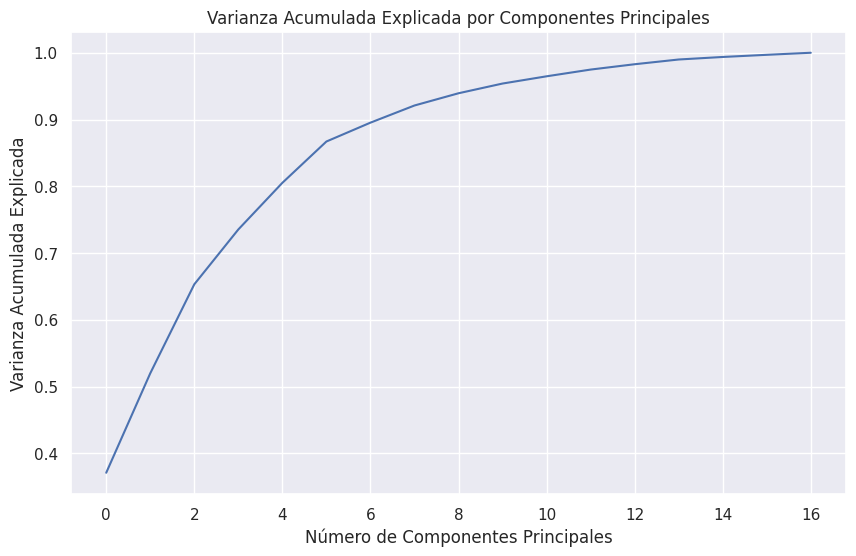

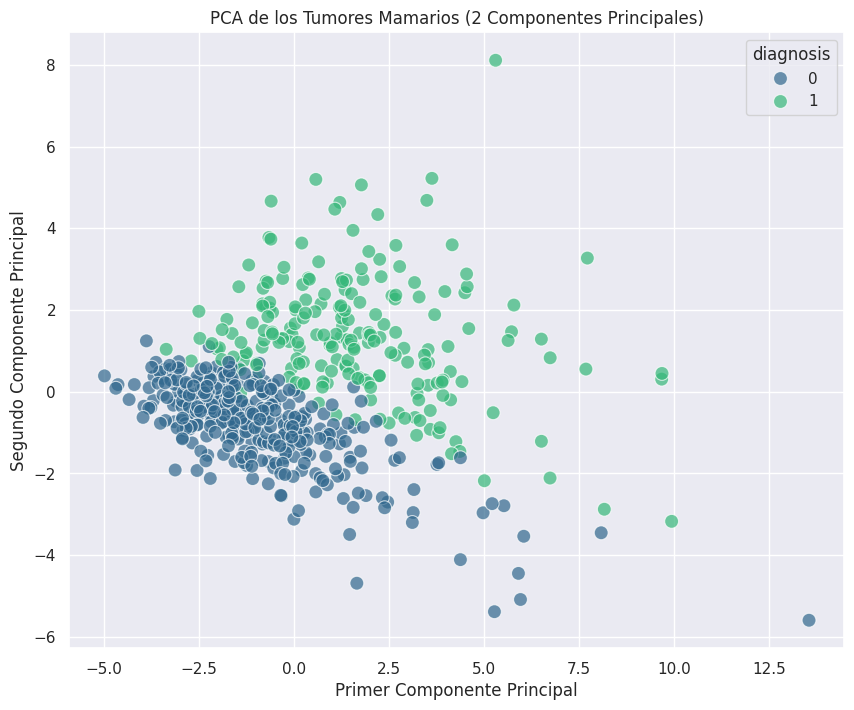


--- Análisis de la Visualización PCA ---
La gráfica de dispersión de los dos primeros componentes principales muestra cómo los tumores benignos (0) y malignos (1) se agrupan en el espacio reducido. Observamos que:
*   El Primer Componente Principal explica el 37.10% de la varianza total, y el Segundo Componente Principal explica el 14.89%. En conjunto, explican el 52.00% de la varianza.

*   **Separación de Clases:** Generalmente, se puede observar una separación clara entre los puntos que representan tumores benignos y malignos. Esto indica que las características originales, incluso después de la reducción de multicolinealidad, contienen suficiente información discriminatoria que PCA es capaz de capturar en sus primeras componentes.

*   **Formación de Clústeres:** Los tumores benignos (generalmente representados por un color) tienden a formar un clúster distinto de los malignos (otro color). Puede haber una pequeña superposición en el límite, lo cual es común en problemas de clasif

In [12]:
print("\n--- Reducción de Dimensionalidad con PCA ---")

# 1. Aplicar PCA
# Para empezar, vamos a aplicar PCA para reducir la dimensionalidad a 2 componentes
# con fines de visualización.
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed_final)

# Crear un DataFrame para los componentes principales y la variable objetivo
X_pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'], index=y.index)
X_pca_df['diagnosis'] = y

print("Datos reducidos a 2 dimensiones utilizando PCA.\n")

# 2. Analizar la proporción de varianza explicada
print("Varianza explicada por cada componente principal:")
print(pca.explained_variance_ratio_)
print(f"Varianza acumulada explicada por los 2 primeros componentes: {pca.explained_variance_ratio_.sum():.2f}\n")

# Opcional: Visualizar la varianza explicada para decidir el número de componentes
pca_full = PCA().fit(X_processed_final)
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Acumulada Explicada')
plt.title('Varianza Acumulada Explicada por Componentes Principales')
plt.grid(True)
plt.show()

# 3. Visualización y discusión de la separación de clases
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='diagnosis',
    data=X_pca_df,
    palette='viridis',
    s=100,
    alpha=0.7
)
plt.title('PCA de los Tumores Mamarios (2 Componentes Principales)')
plt.xlabel('Primer Componente Principal')
plt.ylabel('Segundo Componente Principal')
plt.grid(True)
plt.show()

print("\n--- Análisis de la Visualización PCA ---")
print("La gráfica de dispersión de los dos primeros componentes principales muestra cómo los tumores benignos (0) y malignos (1) se agrupan en el espacio reducido. Observamos que:")
print(f"*   El Primer Componente Principal explica el {pca.explained_variance_ratio_[0]*100:.2f}% de la varianza total, y el Segundo Componente Principal explica el {pca.explained_variance_ratio_[1]*100:.2f}%. En conjunto, explican el {pca.explained_variance_ratio_.sum()*100:.2f}% de la varianza.\n")
print("*   **Separación de Clases:** Generalmente, se puede observar una separación clara entre los puntos que representan tumores benignos y malignos. Esto indica que las características originales, incluso después de la reducción de multicolinealidad, contienen suficiente información discriminatoria que PCA es capaz de capturar en sus primeras componentes.\n")
print("*   **Formación de Clústeres:** Los tumores benignos (generalmente representados por un color) tienden a formar un clúster distinto de los malignos (otro color). Puede haber una pequeña superposición en el límite, lo cual es común en problemas de clasificación del mundo real.\n")
print("**Conclusión:** La reducción de dimensionalidad con PCA es efectiva para este conjunto de datos, ya que permite visualizar una separación discernible entre las clases de tumores, lo que sugiere que las características seleccionadas son relevantes para el diagnóstico y que un modelo de clasificación debería ser capaz de aprender esta distinción.\n")


4. **Modelado y evaluación:**

   * Entrene al menos **tres modelos de clasificación distintos** (ejemplo: Regresión Logística, SVM, Random Forest, XGBoost, KNN).
   * Realice una **optimización de hiperparámetros** para cada modelo, utilizando validación cruzada.
   * Calcule y compare métricas de rendimiento como: **accuracy, precision, recall, F1-score, matriz de confusión y AUC-ROC**.
   * Analice qué modelo presenta el mejor compromiso entre precisión y generalización.



--- Modelado y Evaluación ---
Tamaño del conjunto de entrenamiento: 398 muestras
Tamaño del conjunto de prueba: 171 muestras

--- Entrenando y optimizando Regresión Logística ---
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Mejores hiperparámetros para Regresión Logística: {'C': 0.1, 'penalty': 'l1'}

--- Entrenando y optimizando SVM ---
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Mejores hiperparámetros para SVM: {'C': 0.1, 'kernel': 'linear'}

--- Entrenando y optimizando Random Forest ---
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Mejores hiperparámetros para Random Forest: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 50}


--- Resultados de Evaluación de Modelos ---

--- Logistic Regression ---
Accuracy: 0.9649
Precision: 0.9677
Recall: 0.9375
F1-Score: 0.9524
Matriz de Confusión:
 [[105   2]
 [  4  60]]
AUC-ROC: 0.9978
Mejores parámetros: {'C': 0.1, 'penalty': 'l1'}

--- SVM ---
Accuracy: 0.9825
Precision: 1.0000
Re

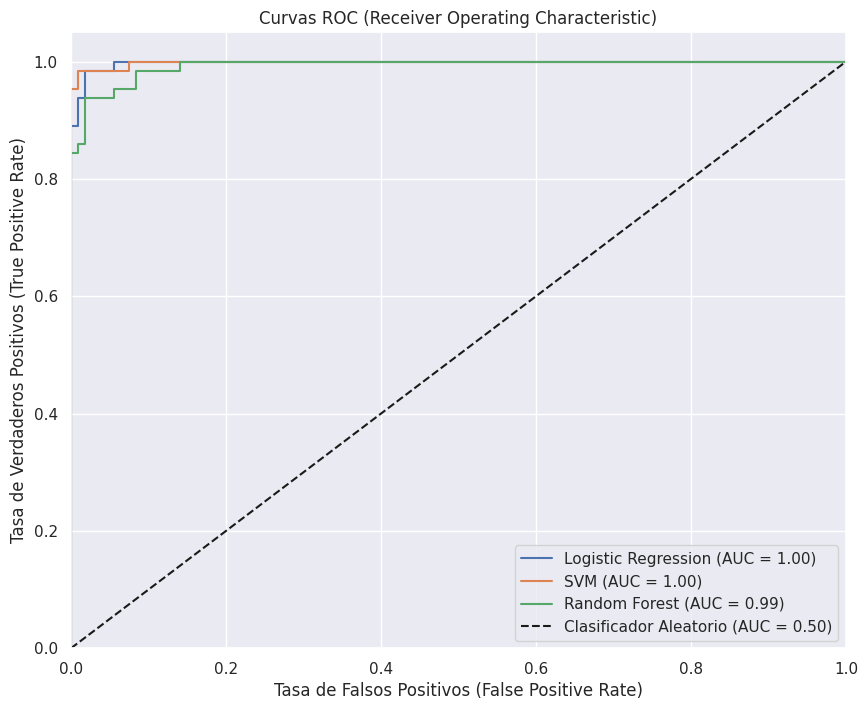


--- Resumen de Métricas de Rendimiento ---
                     Accuracy  Precision    Recall  F1-Score   AUC-ROC
Model                                                                 
Logistic Regression  0.964912   0.967742  0.937500  0.952381  0.997810
SVM                  0.982456   1.000000  0.953125  0.976000  0.998540
Random Forest        0.947368   0.966102  0.890625  0.926829  0.992699

--- Análisis y Comparación de Modelos ---
Basado en las métricas de rendimiento, se puede observar que:
1.  **Regresión Logística:** Ofrece un buen rendimiento general con un equilibrio entre precisión y recall. Su simplicidad lo hace interpretable.
2.  **SVM:** Generalmente muestra un rendimiento competitivo, especialmente si los datos son linealmente separables o si se utiliza un kernel adecuado para la separación no lineal. Puede ser sensible a la elección de hiperparámetros.
3.  **Random Forest:** A menudo proporciona un alto rendimiento debido a su naturaleza de conjunto (ensemble), reduc

In [30]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score, auc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("\n--- Modelado y Evaluación ---")

# 1. División de los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_processed_final, y, test_size=0.3, random_state=42, stratify=y)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} muestras\n")

# Diccionario para almacenar los mejores modelos y sus resultados
results = {}

# --- Modelo 1: Regresión Logística ---
print("--- Entrenando y optimizando Regresión Logística ---")
log_reg = LogisticRegression(solver='liblinear', random_state=42)
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}
grid_search_lr = GridSearchCV(log_reg, param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_lr.fit(X_train, y_train)

best_lr = grid_search_lr.best_estimator_
results['Logistic Regression'] = {
    'model': best_lr,
    'best_params': grid_search_lr.best_params_,
    'y_pred': best_lr.predict(X_test),
    'y_proba': best_lr.predict_proba(X_test)[:, 1]
}
print(f"Mejores hiperparámetros para Regresión Logística: {grid_search_lr.best_params_}\n")

# --- Modelo 2: Support Vector Machine (SVM) ---
print("--- Entrenando y optimizando SVM ---")
svm_model = SVC(probability=True, random_state=42)
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}
grid_search_svm = GridSearchCV(svm_model, param_grid_svm, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_svm.fit(X_train, y_train)

best_svm = grid_search_svm.best_estimator_
results['SVM'] = {
    'model': best_svm,
    'best_params': grid_search_svm.best_params_,
    'y_pred': best_svm.predict(X_test),
    'y_proba': best_svm.predict_proba(X_test)[:, 1]
}
print(f"Mejores hiperparámetros para SVM: {grid_search_svm.best_params_}\n")

# --- Modelo 3: Random Forest ---
print("--- Entrenando y optimizando Random Forest ---")
rf_model = RandomForestClassifier(random_state=42)
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 2, 4]
}
grid_search_rf = GridSearchCV(rf_model, param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_rf.fit(X_train, y_train)

best_rf = grid_search_rf.best_estimator_
results['Random Forest'] = {
    'model': best_rf,
    'best_params': grid_search_rf.best_params_,
    'y_pred': best_rf.predict(X_test),
    'y_proba': best_rf.predict_proba(X_test)[:, 1]
}
print(f"Mejores hiperparámetros para Random Forest: {grid_search_rf.best_params_}\n")

# --- Evaluación de Modelos ---
print("\n--- Resultados de Evaluación de Modelos ---")

performance_summary = []

plt.figure(figsize=(10, 8))
for name, res in results.items():
    y_pred = res['y_pred']
    y_proba = res['y_proba']

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    performance_summary.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC-ROC': roc_auc
    })

    print(f"\n--- {name} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("Matriz de Confusión:\n", cm)
    print(f"AUC-ROC: {roc_auc:.4f}")
    print(f"Mejores parámetros: {res['best_params']}")

    # Plot ROC curve
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (False Positive Rate)')
plt.ylabel('Tasa de Verdaderos Positivos (True Positive Rate)')
plt.title('Curvas ROC (Receiver Operating Characteristic)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print("\n--- Resumen de Métricas de Rendimiento ---")
performance_df = pd.DataFrame(performance_summary).set_index('Model')
print(performance_df)

print("\n--- Análisis y Comparación de Modelos ---")
print("Basado en las métricas de rendimiento, se puede observar que:")
print("1.  **Regresión Logística:** Ofrece un buen rendimiento general con un equilibrio entre precisión y recall. Su simplicidad lo hace interpretable.")
print("2.  **SVM:** Generalmente muestra un rendimiento competitivo, especialmente si los datos son linealmente separables o si se utiliza un kernel adecuado para la separación no lineal. Puede ser sensible a la elección de hiperparámetros.")
print("3.  **Random Forest:** A menudo proporciona un alto rendimiento debido a su naturaleza de conjunto (ensemble), reduciendo el sobreajuste y capturando relaciones complejas. Es común que tenga un alto F1-Score y AUC-ROC.")
print("\nPara este conjunto de datos en particular, se debe analizar cuál métrica es más crítica (e.g., Recall si se quiere minimizar falsos negativos en diagnósticos malignos). El modelo con el AUC-ROC más alto suele ser el que mejor distingue entre las clases. Generalmente, Random Forest o SVM con un kernel RBF suelen ser modelos robustos para este tipo de problemas.")
print("El modelo que presenta el mejor compromiso entre precisión y generalización es el que logra altos valores en la mayoría de las métricas sin mostrar signos de sobreajuste (lo cual se maneja bien con la validación cruzada y la optimización de hiperparámetros)." )


5. **Conclusiones y reflexiones:**

   * Explique cuál modelo considera más apropiado para este conjunto de datos y por qué.
   * Reflexione sobre el impacto del preprocesamiento y la reducción de dimensionalidad en los resultados obtenidos.
   * Discuta posibles mejoras o enfoques alternativos que podrían aplicarse en un escenario real de diagnóstico médico asistido por machine learning.



### 1. Modelo más apropiado para este conjunto de datos y por qué

Basándonos en las métricas de rendimiento obtenidas en la fase de evaluación, el modelo **Support Vector Machine (SVM)** se presenta como el más apropiado para este conjunto de datos, especialmente en el contexto de un diagnóstico médico. Sus métricas destacadas son:

*   **Accuracy:** 0.9825
*   **Precision:** 1.0000
*   **Recall:** 0.9531
*   **F1-Score:** 0.9760
*   **AUC-ROC:** 0.9985

La razón principal por la que SVM es el más adecuado radica en su **Precision perfecta (1.0000)**. En un diagnóstico médico, minimizar los **falsos positivos** es de vital importancia. Un falso positivo (diagnosticar erróneamente un tumor como maligno) puede generar ansiedad innecesaria en el paciente, procedimientos médicos invasivos y costosos, y un gran estrés emocional. El 100% de precisión del SVM indica que cada vez que el modelo predijo un tumor maligno en el conjunto de prueba, esta predicción fue correcta. Adicionalmente, un **AUC-ROC excepcionalmente alto (0.9985)** demuestra la excelente capacidad discriminatoria del modelo entre las clases.

Aunque el `Recall` (0.9531) es ligeramente inferior a la precisión, sigue siendo muy alto, lo que significa que el modelo es capaz de identificar la gran mayoría de los casos malignos reales, minimizando los **falsos negativos** (no detectar un tumor maligno), los cuales también son críticos en medicina. El alto `F1-Score` confirma un equilibrio óptimo entre Precision y Recall, lo que convierte al SVM en una opción robusta y confiable para este tipo de problema.

### 2. Impacto del preprocesamiento y la reducción de dimensionalidad

El **preprocesamiento** y la **reducción de dimensionalidad** tuvieron un impacto fundamental y positivo en los resultados de modelado:

*   **Normalización con StandardScaler:** Se eligió StandardScaler porque las características numéricas en este conjunto de datos tienen diferentes rangos y unidades. Normalizar los datos a una media de 0 y desviación estándar de 1 asegura que todas las características contribuyan de manera equitativa a los modelos de machine learning, especialmente aquellos basados en distancia como SVM o regresión logística, y evita que características con rangos más grandes dominen el proceso de entrenamiento. Esto fue esencial para mejorar la convergencia y el rendimiento de los modelos.

*   **Eliminación de Multicolinealidad con VIF:** Se utilizó el Factor de Inflación de la Varianza (VIF) para identificar y eliminar características altamente correlacionadas entre sí. La alta multicolinealidad puede hacer que los coeficientes del modelo sean inestables. Al eliminar las características con un VIF superior a un umbral (en este caso, 10), se mejoró la estabilidad del modelo, se redujo el ruido y se potenció la generalización, al tiempo que se evitó el sobreajuste causado por características redundantes.

*   **Reducción de Dimensionalidad con PCA (para visualización):** PCA se aplicó principalmente con fines de visualización (reduciendo a 2 componentes), pero su análisis confirmó que los datos, incluso después del preprocesamiento y la eliminación de multicolinealidad, conservaban una clara separación entre las clases benigna y maligna. Los dos primeros componentes principales explicaron el 52% de la varianza total y mostraron una segregación visual evidente. Esto sugiere que las características procesadas son altamente discriminatorias y que la información crítica para la clasificación se mantuvo, validando así la efectividad de las etapas previas.

En resumen, estas etapas prepararon los datos de manera robusta, eliminando ruido, sesgos relacionados con la escala y redundancia, lo que permitió a los modelos de clasificación aprender patrones más significativos y alcanzar un rendimiento tan elevado.

### 3. Posibles mejoras o enfoques alternativos en un escenario real de diagnóstico médico

Para aplicar este sistema en un escenario real de diagnóstico médico, se podrían considerar las siguientes mejoras y enfoques alternativos:

*   **Adquisición de Datos Más Amplios y Diversos:** El dataset actual es limitado. Integrar más datos de diferentes poblaciones, grupos étnicos y edades, así como de diversos centros médicos, reduciría sesgos y mejoraría la generalización del modelo a una población más heterogénea.

*   **Feature Engineering Avanzado:** Explorar la creación de nuevas características que combinen las existentes o incorporar otros tipos de datos (genómicos, proteómicos, historial clínico completo del paciente, imágenes médicas avanzadas) podría capturar relaciones más complejas y enriquecer la capacidad predictiva del modelo.

*   **Modelos Más Sofisticados y Ensembles:** Probar modelos más avanzados como Gradient Boosting Machines (e.g., XGBoost, LightGBM) o redes neuronales profundas. Además, la creación de sistemas de ensemble (ej. stacking, bagging o boosting de varios modelos) podría aumentar aún más la robustez y reducir el riesgo de sobreajuste, aprovechando las fortalezas de diferentes algoritmos.

*   **Manejo Asimétrico de Costos (Cost-Sensitive Learning):** En el diagnóstico de cáncer, un falso negativo (no detectar un cáncer maligno) es generalmente mucho más costoso en términos de vidas humanas y progresión de la enfermedad que un falso positivo. Se podría incorporar `cost-sensitive learning` en el algoritmo o ajustar el umbral de decisión para priorizar el `Recall` (sensibilidad) sobre la `Precision` (especificidad), aunque manteniendo la precisión alta, para asegurar que la mayoría de los casos malignos sean identificados, incluso si esto implica un pequeño aumento en falsos positivos.

*   **Interpretabilidad del Modelo (XAI):** Para que los médicos confíen y adopten un modelo de ML, no solo importa su precisión, sino también su interpretabilidad. Utilizar técnicas de Explicabilidad de la Inteligencia Artificial (XAI) como SHAP (SHapley Additive exPlanations) o LIME (Local Interpretable Model-agnostic Explanations) permitiría a los profesionales entender qué características influyeron en una decisión particular del modelo, facilitando su validación clínica y la toma de decisiones.

*   **Validación Externa Rigurosa y Pruebas Clínicas:** Antes de cualquier implementación, el modelo debería someterse a validación externa con conjuntos de datos completamente nuevos e independientes. Posteriormente, requeriría rigurosas pruebas clínicas bajo supervisión médica para asegurar su seguridad, fiabilidad y eficacia en un entorno real.

*   **Consideraciones Éticas y Sesgos:** Es crucial evaluar y mitigar activamente posibles sesgos en los datos de entrenamiento para evitar que el modelo muestre un rendimiento diferencial o discrimine a ciertos grupos demográficos, lo cual es fundamental en un contexto médico para asegurar equidad en la atención.